In [1]:
import zipfile
import os
import shutil
import random
import numpy as np
import pandas as pd
import cv2
import skimage
import matplotlib.pyplot as plt
import skimage.segmentation
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
    BatchNormalization, Input, Concatenate, 
    GlobalAveragePooling2D, Multiply
)
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

# Setup Jupyter visuals
%matplotlib inline
plt.style.use('ggplot')

ModuleNotFoundError: No module named 'numpy'

In [4]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Extract dataset
z = zipfile.ZipFile("archive.zip")
z.extractall()

In [5]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Extract dataset
z = zipfile.ZipFile("archive.zip")
z.extractall()

In [6]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 224  # Increased from 128

def get_data(data_dir):
    data = []  
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_src = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img_src = cv2.equalizeHist(img_src)  # Histogram equalization
                resized_arr = cv2.resize(img_src, (img_size, img_size))
                resized_arr = np.stack((resized_arr,)*3, axis=-1)  # Convert to 3 channels
                resized_arr = resized_arr / 255.0  # Normalize
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img}: {e}")
    return np.array(data, dtype=object)

# Load datasets
train = get_data("chest_xray/chest_xray/train")
test = get_data("chest_xray/chest_xray/test")
val = get_data("chest_xray/chest_xray/val")

# Prepare X and y
X_train = np.array([x[0] for x in train])
y_train = np.array([x[1] for x in train])
X_test = np.array([x[0] for x in test])
y_test = np.array([x[1] for x in test])
X_val = np.array([x[0] for x in val])
y_val = np.array([x[1] for x in val])

Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'

Error reading .DS_Store: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'



In [7]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [8]:
def build_hybrid_model(input_shape=(img_size, img_size, 3)):
    base_model = DenseNet121(
        include_top=False, 
        weights='imagenet', 
        input_shape=input_shape
    )
    base_model.trainable = False  # Freeze base model
    
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    
    # Attention mechanism
    attention = Dense(256, activation='relu')(x)
    attention = BatchNormalization()(attention)
    attention = Dropout(0.5)(attention)
    attention = Dense(1, activation='sigmoid')(attention)  # Fixed layer output
    
    weighted_features = Multiply()([x, attention])
    
    # Custom head
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(weighted_features)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)
    
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    return Model(inputs, outputs)

model = build_hybrid_model()
model.summary()  # Verify architecture

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_1[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    262,400 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1024)      │          0 │ global_average_p… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    524,800 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        257 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,960,642 (30.37 MB)

 Trainable params: 921,090 (3.51 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [9]:
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7),
    ModelCheckpoint('best_model.h5', save_best_only=True),
    TensorBoard(log_dir='./logs')
]

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights
)

c:\Users\anush\Desktop\M3\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6255 - auc: 0.7590 - loss: 10.0862 - precision: 0.3916 - recall: 0.8167

163/163 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.6258 - auc: 0.7594 - loss: 10.0812 - precision: 0.3919 - recall: 0.8172 - val_accuracy: 0.8750 - val_auc: 0.8906 - val_loss: 7.7745 - val_precision: 0.8000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7596 - auc: 0.8969 - loss: 7.3189 - precision: 0.5237 - recall: 0.9441

163/163 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.7596 - auc: 0.8970 - loss: 7.3161 - precision: 0.5238 - recall: 0.9441 - val_accuracy: 0.8125 - val_auc: 0.8906 - val_loss: 6.1302 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8071 - auc: 0.9124 - loss: 5.7723 - precision: 0.5875 - recall: 0.9252

163/163 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8072 - auc: 0.9124 - loss: 5.7704 - precision: 0.5875 - recall: 0.9253 - val_accuracy: 0.8750 - val_auc: 0.9297 - val_loss: 5.1054 - val_precision: 0.8000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8499 - auc: 0.9423 - loss: 4.7389 - precision: 0.6384 - recall: 0.9442

...

163/163 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9319 - auc: 0.9797 - loss: 0.3298 - precision: 0.8124 - recall: 0.9532 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2772 - val_precision: 0.8000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 41/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9324 - auc: 0.9794 - loss: 0.3246 - precision: 0.8153 - recall: 0.9546 - val_accuracy: 0.9375 - val_auc: 0.9688 - val_loss: 0.3257 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 42/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1119s 7s/step - accuracy: 0.9343 - auc: 0.9830 - loss: 0.2988 - precision: 0.8187 - recall: 0.9618 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.3220 - val_precision: 0.8000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 43/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9328 - auc: 0.9799 - loss: 0.3090 - precision: 0.8284 - recall: 0.9431 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.3

163/163 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9357 - auc: 0.9821 - loss: 0.2859 - precision: 0.8276 - recall: 0.9464 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.2696 - val_precision: 1.0000 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 45/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9413 - auc: 0.9844 - loss: 0.2681 - precision: 0.8415 - recall: 0.9492 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2895 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 46/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9471 - auc: 0.9850 - loss: 0.2571 - precision: 0.8621 - recall: 0.9467

163/163 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9471 - auc: 0.9850 - loss: 0.2571 - precision: 0.8620 - recall: 0.9467 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.2430 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 47/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9326 - auc: 0.9773 - loss: 0.2894 - precision: 0.8231 - recall: 0.9406 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.2455 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 48/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9394 - auc: 0.9835 - loss: 0.2551 - precision: 0.8439 - recall: 0.9361

163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9394 - auc: 0.9835 - loss: 0.2551 - precision: 0.8438 - recall: 0.9362 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.2352 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 49/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9414 - auc: 0.9856 - loss: 0.2399 - precision: 0.8408 - recall: 0.9540

163/163 ━━━━━━━━━━━━━━━━━━━━ 474s 3s/step - accuracy: 0.9414 - auc: 0.9856 - loss: 0.2398 - precision: 0.8409 - recall: 0.9540 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.2150 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 50/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9409 - auc: 0.9848 - loss: 0.2353 - precision: 0.8408 - recall: 0.9531 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.2291 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-04


In [15]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model.save(filepath="model_weight/vgg19_model_001.h5",overwrite=True)

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 976ms/step - accuracy: 0.9224 - auc: 0.4110 - loss: 0.2889 - precision: 0.3353 - recall: 0.3425

Test Accuracy: 0.8798
Test Precision: 0.8841
Test Recall: 0.7821
Test AUC: 0.9531
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step 


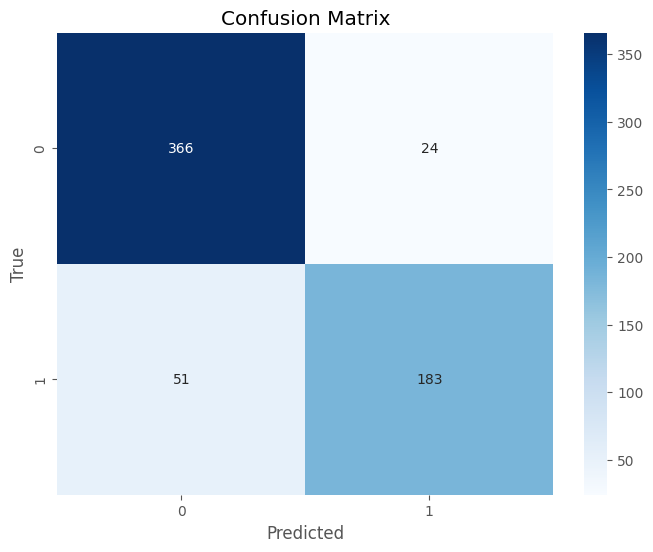

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       390
           1       0.88      0.78      0.83       234

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624



In [11]:
test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test, y_pred_classes))

In [12]:
# Unfreeze last 20 layers of base model
model.layers[1].trainable = True
for layer in model.layers[1].layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 856s 5s/step - accuracy: 0.8730 - loss: 0.4690 - val_accuracy: 0.6250 - val_loss: 1.2696 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 819s 5s/step - accuracy: 0.9582 - loss: 0.2073 - val_accuracy: 0.6875 - val_loss: 1.0878 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 827s 5s/step - accuracy: 0.9773 - loss: 0.1523 - val_accuracy: 0.6250 - val_loss: 1.1032 - learning_rate: 1.0000e-05
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 786s 5s/step - accuracy: 0.9885 - loss: 0.1260 - val_accuracy: 0.8125 - val_loss: 0.3952 - learning_rate: 1.0000e-05
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2206s 14s/step - accuracy: 0.9901 - loss: 0.1126 - val_accuracy: 0.8750 - val_loss: 0.4665 - learning_rate: 1.0000e-05
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 770s 5s/step - accuracy: 0.9937 - loss: 0.0991 - val_accuracy: 0.8750 - val_loss: 0.3120 - learning_rate: 1.0000e-05
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 926s 6s/step - a

In [16]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model.save(filepath="model_weight/vgg19_model_final.h5",overwrite=True)

In [13]:
import os
print(os.listdir())  # Will show 'best_model.h5' if saved

['.venv', 'archive.zip', 'asas.html', 'best_model.h5', 'chest_xray', 'Deep Learning Framework for Pneumonia Detection Using Chest X-Rays with VGG19 and Layer-wis (1) final thesis.docx', 'hybrid.ipynb', 'logs', 'lucide-react-INSTALL.txt', 'model.h5', 'model_weight', 'model_weights', 'node_modules', 'output4.png', 'output5.png', 'package-lock.json', 'package.json', 'Pnuemonia.ipynb', 'predict.py', 'predict3.py', 'public', 'server.js', 'server3.js', 'src', 'test.html', 'Thesis.ipynb', 'uploads']
